In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


INSTALLING KAGGLE LIBRARY

In [ ]:
! pip install kaggle

In [ ]:
# 1) Upload the kaggle.json file from your local machine via the Colab file-picker
from google.colab import files
uploaded = files.upload()   # choose the kaggle.json file downloaded from your Kaggle account

# 2) Create the .kaggle folder and move the uploaded file there
!mkdir -p /root/.kaggle
!cp kaggle.json /root/.kaggle/

# 3) Set strict permissions so the file is not world-readable
!chmod 600 /root/.kaggle/kaggle.json

# 4) Optional: verify the file is in place
!ls -la /root/.kaggle


Saving training.1600000.processed.noemoticon.csv.zip to training.1600000.processed.noemoticon.csv.zip
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
total 12
drwxr-xr-x 2 root root 4096 Jan  8 04:59 .
drwx------ 1 root root 4096 Jan  8 04:59 ..


UPLOAD THE kaggle.json file

In [ ]:
# configuring the path of kaggle.json file
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


**DATA COLLECTION** - IMPORTING KAGGLE TWITTER SENTIMENT DATASET

In [ ]:
# API to fetch the dataset from kaggle
!kaggle datasets download -d kazanova/sentiment140

Traceback (most recent call last):
  File "/usr/local/bin/kaggle", line 10, in <module>
    sys.exit(main())
             ^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/cli.py", line 68, in main
    out = args.func(**command_args)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 1741, in dataset_download_cli
    with self.build_kaggle_client() as kaggle:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 688, in build_kaggle_client
    username=self.config_values['username'],
             ~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^
KeyError: 'username'


In [ ]:
# Extracting the compressed csv dataset from the zip file

from zipfile import ZipFile   # 'zipfile' is a lirary in python & 'ZipFile' is a module
dataset = '/content/training.1600000.processed.noemoticon.csv.zip'  # path of the compressed file that we want to extract

with ZipFile(dataset,'r') as zip:     # opening the file in read mode
  zip.extractall()
  print('Dataset is extracted')

Dataset is extracted


**IMPORTING THE DEPENDENCIES (LIBRARIES AND MODULES)**

In [ ]:
!pip install wordcloud

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import re   # regular expression (for pattern matching)
from nltk.corpus import stopwords  # nltk -> natural langage toolkit  ;  stopwords -> a, an, the, is, for, by, my, etc. (nltk=library , corpus=module)
from nltk.stem.porter import PorterStemmer  # Stemming -> reducing a word into it's root/key word
from sklearn.feature_extraction.text import TfidfVectorizer  # It changes the textual data into numerical data, so that we can feed it to the ML model
from sklearn.model_selection import train_test_split   # It splits entire data into training and testing data ; training data -> trains ML model, test data -> tests/evaluates the model
from sklearn.linear_model import LogisticRegression  # LR is the ML model that we our using
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

**EDA (EXPLORATORY DATA ANALYSIS)**

In [ ]:
# Loading the data from csv file to pandas dataframe
twitter_data= pd.read_csv('/content/training.1600000.processed.noemoticon.csv.zip', encoding="ISO-8859-1")

In [ ]:
# Printing the first 5 rows
twitter_data.head()

,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer. You shoulda got David Carr of Third Day to do it. ;D"
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew


Here, pd.read_csv is not reading the column names ; it's considering the first data row as the column names

In [ ]:
# Naming the columns and reading the dataset again

column_names=['target','ids','date','flag','user','text']
twitter_data= pd.read_csv('/content/training.1600000.processed.noemoticon.csv', names=column_names, encoding="ISO-8859-1")

In [ ]:
# Again printing the first 5 rows
twitter_data.head()

,target,ids,date,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [ ]:
# printing any 8 rows
twitter_data.sample(8)

,target,ids,date,flag,user,text
1149916,4,1978394641,Sat May 30 23:13:40 PDT 2009,NO_QUERY,LonFrench,Recommended mileycyrus 'she is great in... tak...
1328768,4,2015567246,Wed Jun 03 05:00:01 PDT 2009,NO_QUERY,nametagscott,"@KirstyWrites Who knows. Shoot, sometimes I do..."
1186221,4,1982909637,Sun May 31 12:08:18 PDT 2009,NO_QUERY,aarthycrazy,@meerasapra really me too... i love mongrels t...
1022128,4,1882735782,Fri May 22 07:23:49 PDT 2009,NO_QUERY,chad_michael,training our CS department on how to use the v...
134655,0,1836304618,Mon May 18 07:45:30 PDT 2009,NO_QUERY,jesuscandelario,The text thing is confusing.
839485,4,1559421723,Sun Apr 19 11:05:49 PDT 2009,NO_QUERY,elektrotraashy,@MissKeriBaby wasup miss keri baby. return the...
1560271,4,2186295794,Mon Jun 15 18:38:08 PDT 2009,NO_QUERY,tehhaner_x,"@xsmooth TÃ©dio [2] I'm going to bed, my mom i..."
95770,0,1792257854,Wed May 13 22:36:36 PDT 2009,NO_QUERY,LstInTheSeeThru,"UGH, Twitter! You're pissing me off! lol"


In [ ]:
# Printing the number of rows and columns of the dataset
twitter_data.shape

(1600000, 6)

In [ ]:
# Printing the information of the data in the columns
twitter_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600000 entries, 0 to 1599999
Data columns (total 6 columns):
 #   Column  Non-Null Count    Dtype 
---  ------  --------------    ----- 
 0   target  1600000 non-null  int64 
 1   ids     1600000 non-null  int64 
 2   date    1600000 non-null  object
 3   flag    1600000 non-null  object
 4   user    1600000 non-null  object
 5   text    1600000 non-null  object
dtypes: int64(2), object(4)
memory usage: 73.2+ MB


In [ ]:
# Printing the statistics
twitter_data.describe()

,target,ids
count,1.600000e+06,1.600000e+06
mean,2.000000e+00,1.998818e+09
std,2.000001e+00,1.935761e+08
min,0.000000e+00,1.467810e+09
25%,0.000000e+00,1.956916e+09
50%,2.000000e+00,2.002102e+09
75%,4.000000e+00,2.177059e+09
max,4.000000e+00,2.329206e+09


In [ ]:
# Checking the ditribution of traget column
twitter_data['target'].value_counts()

,count
target,
0,800000
4,800000


In [ ]:
# Counting the number of missing values in each column
twitter_data.isnull().sum()

,0
target,0
ids,0
date,0
flag,0
user,0
text,0


**GRAPHS & CHARTS**

Sentiment Dsitribution Bar Chart (Shows Class balance)

/tmp/ipython-input-1421257517.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=twitter_data, palette='viridis')


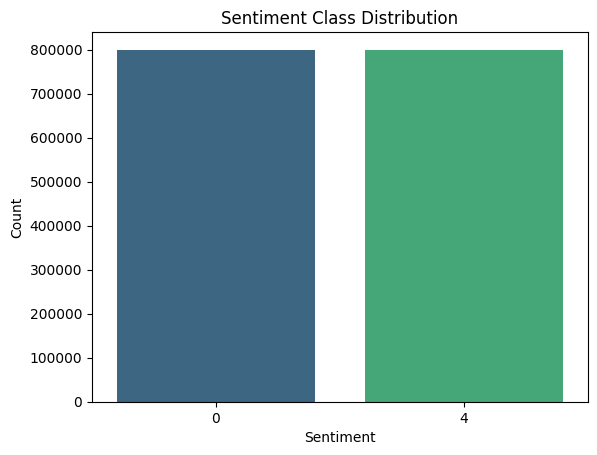

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='target', data=twitter_data, palette='viridis')
plt.title('Sentiment Class Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

Tweet Length Distribution

In [ ]:
twitter_data['tweet_length'] = twitter_data['text'].apply(len)
twitter_data.head()

,target,ids,date,flag,user,text,tweet_length
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",115
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...,111
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...,89
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire,47
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all....",111


Tweet Length Distribution Histogram

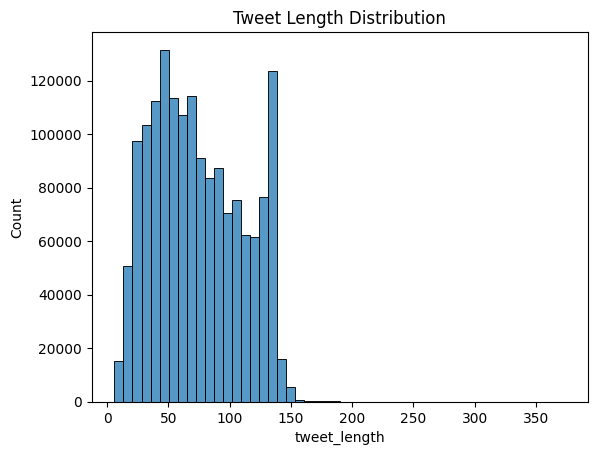

In [ ]:
sns.histplot(twitter_data['tweet_length'], bins=50)
plt.title("Tweet Length Distribution")
plt.show()

Tweet Length Distribution Pie Chart

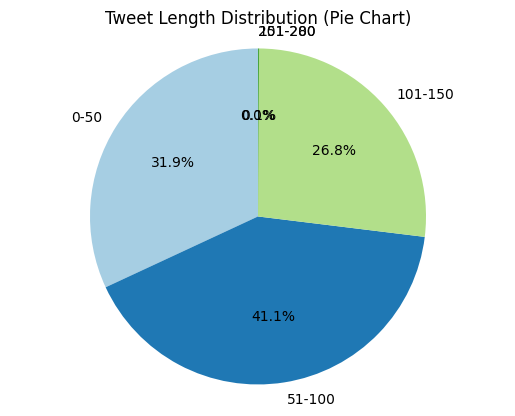

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Calculate tweet length
twitter_data['tweet_length'] = twitter_data['text'].apply(len)

# Define categories
bins = [0, 50, 100, 150, 200, 280]  # Twitter max length = 280 chars
labels = ['0-50', '51-100', '101-150', '151-200', '201-280']

# Categorize tweets
twitter_data['length_category'] = pd.cut(twitter_data['tweet_length'], bins=bins, labels=labels, right=True)

# Count category frequencies
length_counts = twitter_data['length_category'].value_counts().sort_index()

# Plot pie chart
plt.pie(length_counts, labels=length_counts.index, autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)
plt.title('Tweet Length Distribution (Pie Chart)')
plt.axis('equal')  # Equal aspect ratio for perfect circle
plt.show()

Word Clouds - for each sentiment (positive & negative tweets)

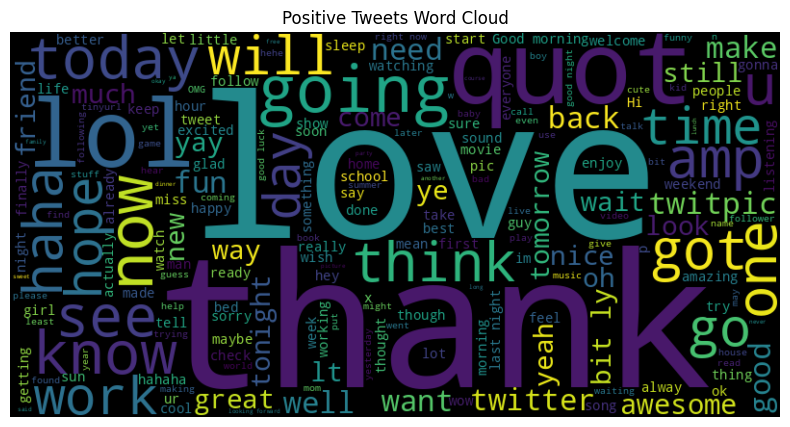

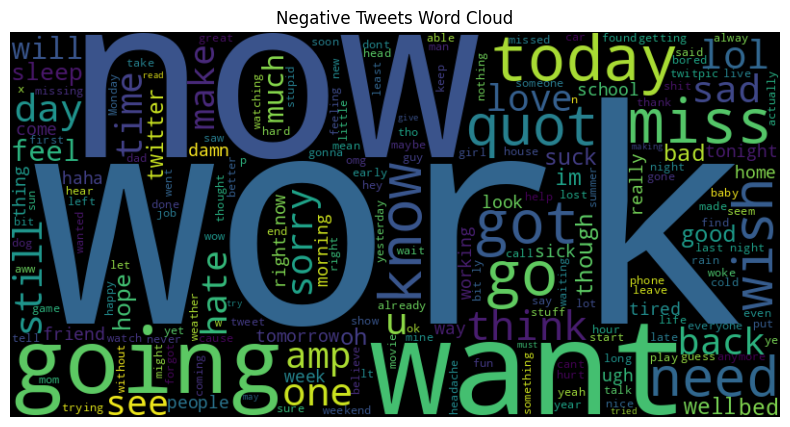

In [ ]:
from wordcloud import WordCloud

pos_text = " ".join(twitter_data[twitter_data['target'] == 4]['text'])
neg_text = " ".join(twitter_data[twitter_data['target'] == 0]['text'])

# Positive tweets word cloud
pos_wc = WordCloud(width=800, height=400).generate(pos_text)
plt.figure(figsize=(10, 5))
plt.imshow(pos_wc, interpolation='bilinear')
plt.axis("off")
plt.title("Positive Tweets Word Cloud")
plt.show()

# Negative tweets word cloud
neg_wc = WordCloud(width=800, height=400).generate(neg_text)
plt.figure(figsize=(10, 5))
plt.imshow(neg_wc, interpolation='bilinear')
plt.axis("off")
plt.title("Negative Tweets Word Cloud")
plt.show()


Most Frequently Used Words

/tmp/ipython-input-2706962931.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequency', y='Word', data=common_words, palette='crest')


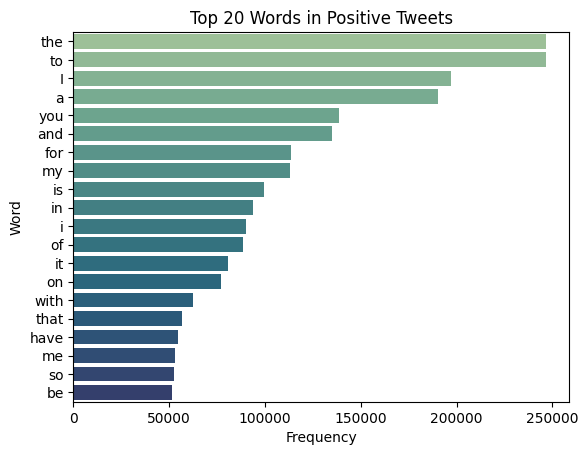

/tmp/ipython-input-2706962931.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequency', y='Word', data=common_words, palette='crest')


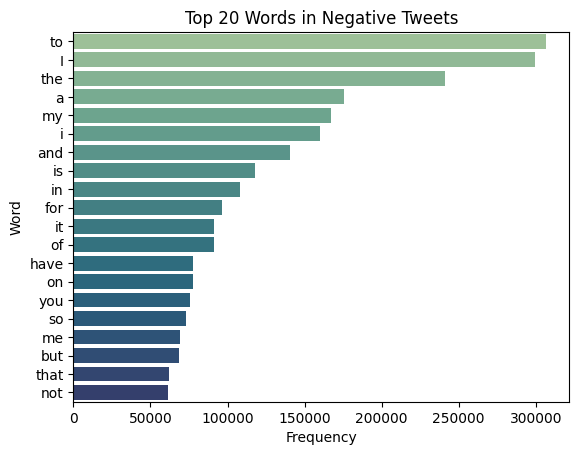

In [ ]:
from collections import Counter
import pandas as pd

# Positive tweets
positive_words = " ".join(twitter_data[twitter_data['target']==4]['text']).split()
word_freq = Counter(positive_words)
common_words = pd.DataFrame(word_freq.most_common(20), columns=['Word', 'Frequency'])

sns.barplot(x='Frequency', y='Word', data=common_words, palette='crest')
plt.title('Top 20 Words in Positive Tweets')
plt.show()

# Negative Tweets
negative_words = " ".join(twitter_data[twitter_data['target']==0]['text']).split()
word_freq = Counter(negative_words)
common_words = pd.DataFrame(word_freq.most_common(20), columns=['Word', 'Frequency'])

sns.barplot(x='Frequency', y='Word', data=common_words, palette='crest')
plt.title('Top 20 Words in Negative Tweets')
plt.show()

**DATA PREPROCESSING**

Converting the target label for positive tweets from '4' -> '1'

In [ ]:
twitter_data.replace({'target':{4:1}},inplace=True)

In [ ]:
twitter_data.sample(5)

,target,ids,date,flag,user,text,tweet_length,length_category
1103982,1,1971108375,Sat May 30 06:14:19 PDT 2009,NO_QUERY,Taylor_Hinson,i'm going to go 'try' to cook.,31,0-50
921649,1,1754242574,Sun May 10 05:33:17 PDT 2009,NO_QUERY,JujuDeRoussie,@alydenisof Happy first Mother's Day to you.,45,0-50
744209,0,2267068359,Sun Jun 21 09:34:22 PDT 2009,NO_QUERY,Fergieferret,Im currently doing a real life version of my a...,127,101-150
1225561,1,1990711147,Mon Jun 01 05:33:44 PDT 2009,NO_QUERY,adzchiq,"@andeecris haha. hey hey, tweet tweet",38,0-50
259386,0,1985415074,Sun May 31 17:03:32 PDT 2009,NO_QUERY,kpatt,soooo bored. I have jury duty tomorrow bummerr.,49,0-50


In [ ]:
# Checking the ditribution of traget column
twitter_data['target'].value_counts()

,count
target,
0,800000
1,800000


'0' --> Negative Tweet


'1' --> Positive Tweet

Dropping columns that are not required

In [ ]:
twitter_data= twitter_data.drop(columns=['ids', 'date', 'flag', 'user'])

In [ ]:
twitter_data.head()

,target,text,tweet_length,length_category
0,0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",115,101-150
1,0,is upset that he can't update his Facebook by ...,111,101-150
2,0,@Kenichan I dived many times for the ball. Man...,89,51-100
3,0,my whole body feels itchy and like its on fire,47,0-50
4,0,"@nationwideclass no, it's not behaving at all....",111,101-150


In [ ]:
twitter_data.shape

(1600000, 4)

Removing Dupliactes

In [ ]:
twitter_data = twitter_data.drop_duplicates(subset='text')

In [ ]:
twitter_data.shape

(1581466, 4)

**DATA CLEANING**

**STEMMING** - Process of reducing a word into it's key/root word

Example - actor,actress,acting = act

&

**REMOVING NOISY TWEETS** - like the ones having emojis, urls, etc which do not affect the sentiment of the tweet

&

**REMOVAL OF STOPWORDS** - Removing words like 'a','an','my', etc. that do not directly affect the sentiment of the tweet

from nltk.stem.porter import PorterStemmer
import re

port_stem = PorterStemmer()

def stemming(content):    # we will pass the text column as content in this stemming function
  stemmed_content= re.sub('[^a-zA-Z]'," ", content)   # Removing everything that is not a lowercase or uppercase letter in the tweet (eg- @,;,etc.)
  stemmed_content= stemmed_content.lower()   # converting upper case letters to lower case letters
  stemmed_content= stemmed_content.split()   # split all the stemmed content words from the teweet and store them in a list
  stemmed_content= [port_stem.stem(word) for word in stemmed_content if not word in stopwords.words('english')]   # Performing stemming & Keeping only the words in the processed stem content that do not belong to the stopwords
  stemmed_content= ' '.join(stemmed_content)   # Joining all the words of stem content of a tweet into a single tweet

  return stemmed_content

- Applying the 'stemming' function to the dataset we have
- Creating a new column called 'stemmed_content'

twitter_data['stemmed_content']= twitter_data['text'].apply(stemming)

In [ ]:
'''
from nltk.stem.porter import PorterStemmer
import re

port_stem = PorterStemmer()
'''

'\nfrom nltk.stem.porter import PorterStemmer\nimport re\n\nport_stem = PorterStemmer()\n'

In [ ]:
'''
def stemming(content):    # we will pass the text column as content in this stemming function
  stemmed_content= re.sub('[^a-zA-Z]'," ", content)   # Removing everything that is not a lowercase or uppercase letter in the tweet (eg- @,;,etc.)
  stemmed_content= stemmed_content.lower()   # converting upper case letters to lower case letters
  stemmed_content= stemmed_content.split()   # split all the stemmed content words from the teweet and store them in a list
  stemmed_content= [port_stem.stem(word) for word in stemmed_content if not word in stopwords.words('english')]   # Performing stemming & Keeping only the words in the processed stem content that do not belong to the stopwords
  stemmed_content= ' '.join(stemmed_content)   # Joining all the words of stem content of a tweet into a single tweet

  return stemmed_content
'''

'\ndef stemming(content):    # we will pass the text column as content in this stemming function\n  stemmed_content= re.sub(\'[^a-zA-Z]\'," ", content)   # Removing everything that is not a lowercase or uppercase letter in the tweet (eg- @,;,etc.)\n  stemmed_content= stemmed_content.lower()   # converting upper case letters to lower case letters\n  stemmed_content= stemmed_content.split()   # split all the stemmed content words from the teweet and store them in a list\n  stemmed_content= [port_stem.stem(word) for word in stemmed_content if not word in stopwords.words(\'english\')]   # Performing stemming & Keeping only the words in the processed stem content that do not belong to the stopwords\n  stemmed_content= \' \'.join(stemmed_content)   # Joining all the words of stem content of a tweet into a single tweet\n\n  return stemmed_content\n'

In [ ]:
'''
# Applying the 'stemming' function to the dataset we have
# Creating a new column called 'stemmed_content'

twitter_data['stemmed_content']= twitter_data['text'].apply(stemming)
'''

"\n# Applying the 'stemming' function to the dataset we have\n# Creating a new column called 'stemmed_content'\n\ntwitter_data['stemmed_content']= twitter_data['text'].apply(stemming)\n"

**LEMMATIZATION**

In [ ]:
# Downloading the stopwords
import nltk
nltk.download('stopwords')

# Printing the stopwords in English
print(stopwords.words('english'))

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
# ADVANCED TEXT PREPROCESSING

# This step cleans the tweets more aggressively than before to reduce noise and improve accuracy.

import re
import string
import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_tweet(text):
    # Lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remove usernames
    text = re.sub(r'@\w+', '', text)
    # Remove hashtags symbol (keep the text)
    text = re.sub(r'#', '', text)
    # Remove emojis and non-ASCII
    text = text.encode('ascii', 'ignore').decode('ascii')
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Remove repeated characters (e.g., loooove -> love)
    text = re.sub(r'(.)\1{2,}', r'\1', text)
    # Tokenize and remove stopwords
    words = text.split()
    words = [w for w in words if w not in stop_words]
    # Lemmatize words
    words = [lemmatizer.lemmatize(w) for w in words]
    return " ".join(words)

# Apply cleaning to the dataset
twitter_data['clean_tweet'] = twitter_data['text'].apply(clean_tweet)
print("Sample cleaned tweets:", twitter_data['clean_tweet'].head())

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


Sample cleaned tweets: 0        thats bummer shoulda got david carr third day
1    upset cant update facebook texting might cry r...
2      dived many time ball managed save rest go bound
3                      whole body feel itchy like fire
4                             behaving im mad cant see
Name: clean_tweet, dtype: object


In [ ]:
twitter_data.sample(5)

,target,text,tweet_length,length_category,clean_tweet
360081,0,@Wiltedrose23 he came in today and I wasn't th...,52,51-100,came today wasnt
53005,0,@zackdft I wish it was nice enough to go outsi...,50,0-50,wish nice enough go outside
1377505,1,@thatonestephano Get 100 followers a day using...,122,101-150,get follower day using add everyone train pay vip
616304,0,It appears that I'm stuck in Atlanta for 2 hrs...,66,51-100,appears im stuck atlanta hrswhat great day
1526920,1,"@Pattiebelle Pattie Going thru my pix, you a...",100,51-100,pattie going thru pix lot loli always crop pos...


In [ ]:
twitter_data.shape

(1581466, 5)

In [ ]:
print(twitter_data['clean_tweet'])

0              thats bummer shoulda got david carr third day
1          upset cant update facebook texting might cry r...
2            dived many time ball managed save rest go bound
3                            whole body feel itchy like fire
4                                   behaving im mad cant see
                                 ...                        
1599995                        woke school best feeling ever
1599996               thewdbcom cool hear old walt interview
1599997                       ready mojo makeover ask detail
1599998     happy th birthday boo al time tupac amaru shakur
1599999                                 happy charitytuesday
Name: clean_tweet, Length: 1581466, dtype: object


In [ ]:
twitter_data['target'].value_counts()

,count
target,
1,791281
0,790185


Randomly selecting a sample of 100k data points

In [ ]:
import pandas as pd

# Assuming your dataframe is called df and target column is "target"

# Separate positive and negative samples
df_pos = twitter_data[twitter_data['target'] == 1]
df_neg = twitter_data[twitter_data['target'] == 0]

# Randomly sample 50k from each
df_pos_sample = df_pos.sample(n=50000, random_state=42)
df_neg_sample = df_neg.sample(n=50000, random_state=42)

# Combine them into one dataframe
df_sample = pd.concat([df_pos_sample, df_neg_sample])

# Shuffle the combined dataset
df_sample = df_sample.sample(frac=1, random_state=42).reset_index(drop=True)

print("Final sampled dataset shape:", df_sample.shape)
print(df_sample['target'].value_counts())


Final sampled dataset shape: (100000, 5)
target
0    50000
1    50000
Name: count, dtype: int64


In [ ]:
df_sample.head()

,target,text,tweet_length,length_category,clean_tweet
0,0,Had a good 3 hour nap..I don't know how I'm go...,73,51-100,good hour napi dont know im gonna pas english ...
1,0,is scared that she might not get the job that ...,98,51-100,scared might get job want im still hoping wish...
2,1,@GenderQ Thanks A friend of mine always says ...,118,101-150,thanks friend mine always say like pretty ligh...
3,0,had an absolutely amazing weekend but now stuc...,70,51-100,absolutely amazing weekend stuck babbage work
4,0,i had really weird dream last night...but i wi...,73,51-100,really weird dream last nightbut wish didnt wake


In [ ]:
# Separating the data (tweet/text) and label(target)
X= df_sample['clean_tweet'].values
Y= df_sample['target'].values

In [ ]:
print(X)

['good hour napi dont know im gonna pas english final'
 'scared might get job want im still hoping wishing pas'
 'thanks friend mine always say like pretty lightsshe see bright side anything'
 ... 'cant stop cry eye im lost' 'im heading brief sunshine catch later'
 'bed working tomorrow']


In [ ]:
print(Y)

[0 0 1 ... 0 1 1]


**DATASET CLEANLINESS METRICS**

In [ ]:
import pandas as pd
import numpy as np
import re

def compute_cleanliness_metrics(twitter_data, orig_col='text', clean_col='clean_tweet', vocab=None):
    # Lengths
    twitter_data['orig_len'] = twitter_data[orig_col].astype(str).apply(len)
    twitter_data['clean_len'] = twitter_data[clean_col].astype(str).apply(len)

    avg_len_original = twitter_data['orig_len'].mean()
    avg_len_cleaned = twitter_data['clean_len'].mean()
    std_len_original = twitter_data['orig_len'].std()
    std_len_cleaned = twitter_data['clean_len'].std()
    percent_chars_removed = 100 * (1 - (twitter_data['clean_len'].sum() / twitter_data['orig_len'].sum()))

    # Tokenization
    twitter_data['orig_tokens'] = twitter_data[orig_col].astype(str).apply(lambda x: x.split())
    twitter_data['clean_tokens'] = twitter_data[clean_col].astype(str).apply(lambda x: x.split())

    # Vocabulary sizes
    orig_vocab = set([tok for tokens in twitter_data['orig_tokens'] for tok in tokens])
    clean_vocab = set([tok for tokens in twitter_data['clean_tokens'] for tok in tokens])

    vocab_size = len(clean_vocab)

    # OOV Rate
    if vocab is not None:
        oov_tokens = [tok for tok in clean_vocab if tok not in vocab]
        oov_rate = (len(oov_tokens) / len(clean_vocab)) * 100 if len(clean_vocab) > 0 else 0
    else:
        oov_rate = np.nan

    # Special tokens breakdown
    def count_specials(text):
        hashtags = len(re.findall(r'#\w+', text))
        mentions = len(re.findall(r'@\w+', text))
        urls = len(re.findall(r'http\S+|www\S+', text))
        emojis = len(re.findall(r'[^\w\s,]', text))  # crude emoji/symbol count
        return hashtags, mentions, urls, emojis

    twitter_data[['hashtags', 'mentions', 'urls', 'emojis']] = twitter_data[orig_col].astype(str).apply(
        lambda x: pd.Series(count_specials(x))
    )

    avg_hashtags = twitter_data['hashtags'].mean()
    avg_mentions = twitter_data['mentions'].mean()
    avg_urls = twitter_data['urls'].mean()
    avg_emojis = twitter_data['emojis'].mean()

    # Final nicely formatted DataFrame
    results = pd.DataFrame([{
        "Avg Length (Original)": avg_len_original,
        "Avg Length (Cleaned)": avg_len_cleaned,
        "Std Dev (Original)": std_len_original,
        "Std Dev (Cleaned)": std_len_cleaned,
        "% Characters Removed": percent_chars_removed,
        "Avg Hashtags": avg_hashtags,
        "Avg Mentions": avg_mentions,
        "Avg URLs": avg_urls,
        "Avg Emojis/Symbols": avg_emojis,
        "Vocabulary Size": vocab_size,
        "OOV Rate (%)": oov_rate
    }])

    return results

# Example usage
metrics = compute_cleanliness_metrics(twitter_data, orig_col='text', clean_col='clean_tweet')
print(metrics)


   Avg Length (Original)  Avg Length (Cleaned)  Std Dev (Original)  \
0              74.475726             42.208015           36.207924   

   Std Dev (Cleaned)  % Characters Removed  Avg Hashtags  Avg Mentions  \
0           23.82152             43.326481      0.027146      0.495537   

   Avg URLs  Avg Emojis/Symbols  Vocabulary Size  OOV Rate (%)  
0  0.051581            3.681955           379639           NaN  


In [ ]:
import pandas as pd
import numpy as np
import re

def compute_cleanliness_metrics(df_sample, orig_col='text', clean_col='clean_tweet', vocab=None):
    # Lengths
    df_sample['orig_len'] = df_sample[orig_col].astype(str).apply(len)
    df_sample['clean_len'] = df_sample[clean_col].astype(str).apply(len)

    avg_len_original = df_sample['orig_len'].mean()
    avg_len_cleaned = df_sample['clean_len'].mean()
    std_len_original = df_sample['orig_len'].std()
    std_len_cleaned = df_sample['clean_len'].std()
    percent_chars_removed = 100 * (1 - (df_sample['clean_len'].sum() / df_sample['orig_len'].sum()))

    # Tokenization
    df_sample['orig_tokens'] = df_sample[orig_col].astype(str).apply(lambda x: x.split())
    df_sample['clean_tokens'] = df_sample[clean_col].astype(str).apply(lambda x: x.split())

    # Vocabulary sizes
    clean_vocab = set([tok for tokens in df_sample['clean_tokens'] for tok in tokens])
    vocab_size = len(clean_vocab)

    # OOV Rate
    if vocab is not None:
        oov_tokens = [tok for tok in clean_vocab if tok not in vocab]
        oov_rate = (len(oov_tokens) / len(clean_vocab)) * 100 if len(clean_vocab) > 0 else 0
    else:
        oov_rate = np.nan

    # Special tokens breakdown
    def count_specials(text):
        hashtags = len(re.findall(r'#\w+', text))
        mentions = len(re.findall(r'@\w+', text))
        urls = len(re.findall(r'http\S+|www\S+', text))
        emojis = len(re.findall(r'[^\w\s,]', text))  # crude emoji/symbol count
        return hashtags, mentions, urls, emojis

    df_sample[['hashtags', 'mentions', 'urls', 'emojis']] = df_sample[orig_col].astype(str).apply(
        lambda x: pd.Series(count_specials(x))
    )

    avg_hashtags = df_sample['hashtags'].mean()
    avg_mentions = df_sample['mentions'].mean()
    avg_urls = df_sample['urls'].mean()
    avg_emojis = df_sample['emojis'].mean()

    # Final vertical table
    results = pd.DataFrame({
        "Metric": [
            "Avg Length (Original)",
            "Avg Length (Cleaned)",
            "Std Dev (Original)",
            "Std Dev (Cleaned)",
            "% Characters Removed",
            "Avg Hashtags",
            "Avg Mentions",
            "Avg URLs",
            "Avg Emojis/Symbols",
            "Vocabulary Size",
            "OOV Rate (%)"
        ],
        "Value": [
            round(avg_len_original, 2),
            round(avg_len_cleaned, 2),
            round(std_len_original, 2),
            round(std_len_cleaned, 2),
            round(percent_chars_removed, 2),
            round(avg_hashtags, 2),
            round(avg_mentions, 2),
            round(avg_urls, 2),
            round(avg_emojis, 2),
            vocab_size,
            round(oov_rate, 2) if not np.isnan(oov_rate) else "NaN"
        ]
    })

    return results

# Example usage
metrics = compute_cleanliness_metrics(df_sample, orig_col='text', clean_col='clean_tweet')
print(metrics)


                   Metric  Value
0   Avg Length (Original)  74.35
1    Avg Length (Cleaned)  42.15
2      Std Dev (Original)  36.19
3       Std Dev (Cleaned)  23.83
4    % Characters Removed  43.31
5            Avg Hashtags   0.03
6            Avg Mentions   0.49
7                Avg URLs   0.05
8      Avg Emojis/Symbols   3.67
9         Vocabulary Size  57494
10           OOV Rate (%)    NaN


In [ ]:
import pandas as pd
import numpy as np
import re
from collections import Counter

# Function to get stats
def compute_cleanliness_metrics(twitter_data, orig_col='text', clean_col='clean_tweet', vocab=None):
    metrics = {}

    # Length stats
    twitter_data['orig_len'] = twitter_data[orig_col].astype(str).apply(len)
    twitter_data['clean_len'] = twitter_data[clean_col].astype(str).apply(len)

    metrics['avg_len_original'] = twitter_data['orig_len'].mean()
    metrics['avg_len_cleaned'] = twitter_data['clean_len'].mean()
    metrics['std_len_original'] = twitter_data['orig_len'].std()
    metrics['std_len_cleaned'] = twitter_data['clean_len'].std()

    # % characters removed
    metrics['percent_chars_removed'] = 100 * (1 - (twitter_data['clean_len'].sum() / twitter_data['orig_len'].sum()))

    # Tokenization
    twitter_data['orig_tokens'] = twitter_data[orig_col].astype(str).apply(lambda x: x.split())
    twitter_data['clean_tokens'] = twitter_data[clean_col].astype(str).apply(lambda x: x.split())

    # Vocabulary
    orig_vocab = set([tok for tokens in twitter_data['orig_tokens'] for tok in tokens])
    clean_vocab = set([tok for tokens in twitter_data['clean_tokens'] for tok in tokens])

    metrics['vocab_size_original'] = len(orig_vocab)
    metrics['vocab_size_cleaned'] = len(clean_vocab)
    metrics['vocab_uniqueness'] = len(clean_vocab) / len(orig_vocab) if len(orig_vocab) > 0 else 0

    # OOV rate (if vocab provided, e.g. GloVe or pretrained embeddings)
    if vocab is not None:
        oov_tokens = [tok for tok in clean_vocab if tok not in vocab]
        metrics['OOV_rate'] = len(oov_tokens) / len(clean_vocab) if len(clean_vocab) > 0 else 0
    else:
        metrics['OOV_rate'] = None  # Need external vocab to compute

    # Special token frequency (hashtags, mentions, URLs, emojis, etc.)
    def count_specials(text):
        hashtags = len(re.findall(r'#\w+', text))
        mentions = len(re.findall(r'@\w+', text))
        urls = len(re.findall(r'http\S+|www\S+', text))
        emojis = len(re.findall(r'[^\w\s,]', text))  # crude emoji/symbol count
        return hashtags + mentions + urls + emojis

    twitter_data['special_tokens'] = twitter_data[orig_col].astype(str).apply(count_specials)
    metrics['avg_special_tokens'] = twitter_data['special_tokens'].mean()

    return pd.Series(metrics)

# Example usage
metrics = compute_cleanliness_metrics(twitter_data, orig_col='text', clean_col='clean_tweet')
print(metrics)


avg_len_original         7.447573e+01
avg_len_cleaned          4.220801e+01
std_len_original         3.620792e+01
std_len_cleaned          2.382152e+01
percent_chars_removed    4.332648e+01
vocab_size_original      1.350598e+06
vocab_size_cleaned       3.796390e+05
vocab_uniqueness         2.810896e-01
OOV_rate                          NaN
avg_special_tokens       4.256219e+00
dtype: float64


**TRAIN-TEST SPLIT**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=42)

# X_train, X_test, Y_train, Y_test are the 4 arrays
# X_train contains all the training data tweets and their corresponding targets are stored in the Y_train
# X_test contains all the test data tweets and their corresponding targets are stored in the Y_test
# test_size= 0.2 --> means 20% of the data is test data and the rest 80% data is used for training the ML model
# stratify=Y --> means that in the training Y_train data & the testing Y_test data , I want an almost equal proportion of 0 and 1 from the target column
# random_state= 'any no' --> everyone using the same value of random_state will have the same rows in the test data and the train data

In [ ]:
print(X.shape, X_train.shape, X_test.shape)

(100000,) (80000,) (20000,)


In [ ]:
print(Y.shape, y_train.shape, y_test.shape)

(100000,) (80000,) (20000,)


In [ ]:
print(X_train)

['fucking usb wipedhad latest itunes itfuck resyncing iphone tonight'
 'waiting train connec late per usual'
 'also ive got quotsex bee sex bee youre sex beequot stuck head' ...
 'missinl friend' 'night crazy world hope sickness gone tomorrow'
 'swallowed ball tongue ring first time feel weird pieace metal inside']


In [ ]:
print(X_test)

['hello said extra tix brand exposure tomorrow still available'
 'oh youre around others thanks hanging around tho hug'
 'dumb computer work wont let block much thanks though' ...
 'going bed watched old tivo pilate whitened teeth folded laundry man feel productive'
 'sent another check damn surgery health care country suck thats call quotgood insurancequot'
 'long beach helping daniella move']


**FEATURE EXTRACTION**

**TF-IDF Vectorizer** --> used to convert textual/raw data into numerical data, that the model can understand, based on the weights given to each word or phrase depeding on it's frequency. Lesser the frequency of a word, more is the wight associated to it.

Then the ML model will associate the numerical data,i.e, weights associated to the words/phrases to the target labels(0 or 1) and work on it.

TF-IDF stands for Term Frequency – Inverse Document Frequency.

It assigns a weight to each word (or phrase) based on:

Term Frequency (TF) → How often the word appears in a tweet.

Inverse Document Frequency (IDF) → How rare the word is across all tweets.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

In [ ]:
X_train= vectorizer.fit_transform(X_train)
X_test= vectorizer.transform(X_test)

In [ ]:
print(X_train)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 551997 stored elements and shape (80000, 49767)>
  Coords	Values
  (0, 15710)	0.2619748846498261
  (0, 46125)	0.33876333325109864
  (0, 48159)	0.4270708557186181
  (0, 23374)	0.3077997293170834
  (0, 21193)	0.288131021654653
  (0, 21126)	0.4270708557186181
  (0, 36017)	0.4270708557186181
  (0, 20908)	0.23793430709062363
  (0, 43946)	0.18726217703129042
  (1, 46970)	0.30255610784311504
  (1, 44314)	0.3528860259288595
  (1, 8651)	0.5775356127101127
  (1, 23341)	0.3041758261178487
  (1, 31334)	0.44103644266973085
  (1, 46169)	0.4041630777362894
  (2, 1228)	0.18531581263520788
  (2, 21228)	0.1630840812295234
  (2, 16996)	0.13349741965814713
  (2, 34523)	0.3473393640482909
  (2, 3743)	0.5439792722336286
  (2, 38103)	0.5164227827416245
  (2, 49453)	0.16801906872636435
  (2, 3766)	0.35992373549557416
  (2, 41156)	0.2084945908249571
  (2, 18319)	0.19168724730028297
  :	:
  (79996, 25215)	0.3013764156437847
  (79996, 2966)	0.27607021

In [ ]:
print(X_test)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 129490 stored elements and shape (20000, 49767)>
  Coords	Values
  (0, 2682)	0.3557171851344096
  (0, 5248)	0.3726895091142448
  (0, 13753)	0.47515911886757833
  (0, 13781)	0.34145770901904643
  (0, 18535)	0.29460716431441003
  (0, 37041)	0.2679105598087505
  (0, 40860)	0.20118365084231174
  (0, 43607)	0.38453999602376393
  (0, 43889)	0.21279788409209535
  (1, 2177)	0.5965304218283328
  (1, 17967)	0.3574521068637794
  (1, 19578)	0.3316946838682188
  (1, 29617)	0.22540027406724508
  (1, 30274)	0.38066311894892707
  (1, 42797)	0.22535161350087463
  (1, 43144)	0.30431333651899617
  (1, 49453)	0.25934230980932027
  (2, 4587)	0.44263661144904004
  (2, 8481)	0.3646212870699581
  (2, 12125)	0.46060950989972105
  (2, 23731)	0.30109323325418746
  (2, 27549)	0.2628927817373203
  (2, 42797)	0.2580038566962303
  (2, 43173)	0.2860678860035676
  (2, 48387)	0.31017254000341704
  :	:
  (19997, 16760)	0.15931845855651813
  (19997, 23415)	0.3

All the words in each tweet get associated to a numerical value.

Example - here all the words in the tweet with 0 index are converted to numerical data

  (0, 222329)	0.45902566553974955
  (0, 286158)	0.36307656788596043
  (0, 358197)	0.30487157492746747
  (0, 408896)	0.663912210812278
  (0, 436771)	0.23863127215930252
  (0, 453351)	0.25845668749555184

**MODEL SELECTION AND TRAINING**

In [ ]:
df_sample.sample(5)

,target,text,tweet_length,length_category,clean_tweet
15306,0,Late night walk. Saw some poor guy get a parki...,66,51-100,late night walk saw poor guy get parking ticke...
41806,0,2 more coronas n I'm done drinking I miss Cybil,49,0-50,corona n im done drinking miss cybil
26046,1,Lying on joels bed..eating chips chillin. Long...,69,51-100,lying joel bedeating chip chillin long day chi...
48230,1,I have a picture though! So don't worry that y...,61,51-100,picture though dont worry missed
69410,1,theological discussion with mom.............so...,52,51-100,theological discussion momso good


Applying all models (Untuned)

Training Logistic Regression...
Logistic Regression Test Accuracy: 0.7657

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.75      0.76     10000
           1       0.76      0.78      0.77     10000

    accuracy                           0.77     20000
   macro avg       0.77      0.77      0.77     20000
weighted avg       0.77      0.77      0.77     20000



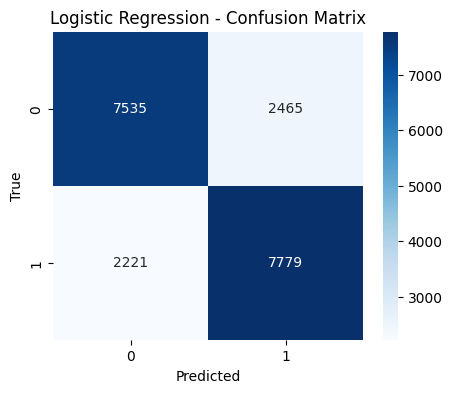

Training Naive Bayes...
Naive Bayes Test Accuracy: 0.7454

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.78      0.75     10000
           1       0.76      0.71      0.74     10000

    accuracy                           0.75     20000
   macro avg       0.75      0.75      0.75     20000
weighted avg       0.75      0.75      0.75     20000



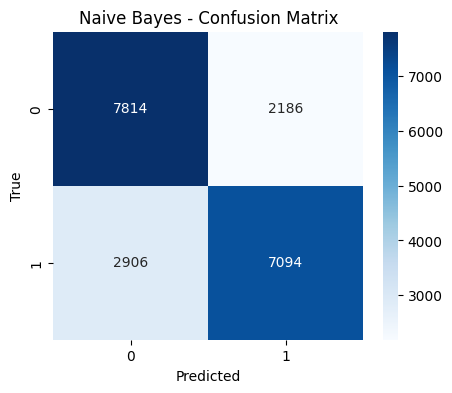

Training Linear SVM...
Linear SVM Test Accuracy: 0.7508

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.74      0.75     10000
           1       0.75      0.76      0.75     10000

    accuracy                           0.75     20000
   macro avg       0.75      0.75      0.75     20000
weighted avg       0.75      0.75      0.75     20000



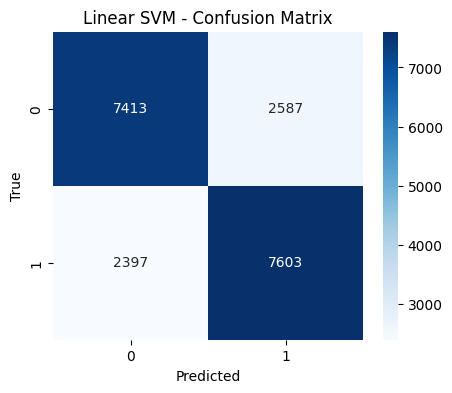

Training KNN...
KNN Test Accuracy: 0.5873

Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.56      0.58     10000
           1       0.58      0.61      0.60     10000

    accuracy                           0.59     20000
   macro avg       0.59      0.59      0.59     20000
weighted avg       0.59      0.59      0.59     20000



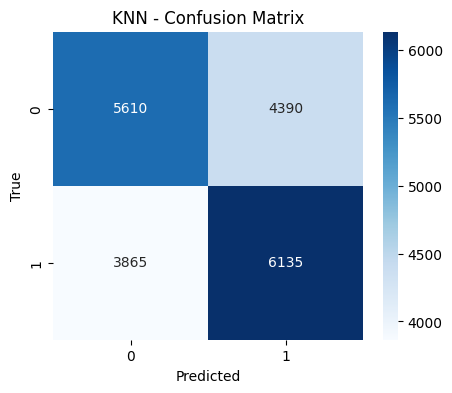

Training Random Forest...
Random Forest Test Accuracy: 0.7557

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.77      0.76     10000
           1       0.76      0.74      0.75     10000

    accuracy                           0.76     20000
   macro avg       0.76      0.76      0.76     20000
weighted avg       0.76      0.76      0.76     20000



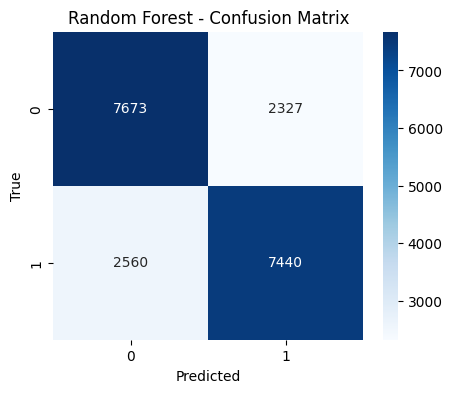

Training XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [08:27:14] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Test Accuracy: 0.7372

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.66      0.72     10000
           1       0.71      0.81      0.76     10000

    accuracy                           0.74     20000
   macro avg       0.74      0.74      0.74     20000
weighted avg       0.74      0.74      0.74     20000



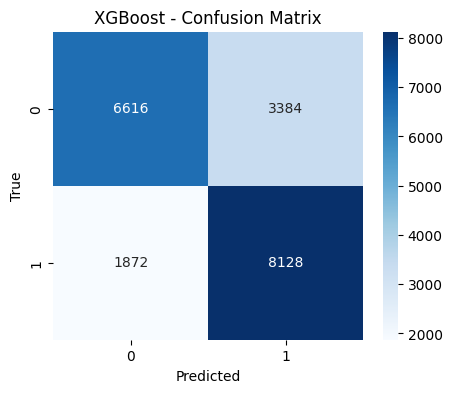

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [08:38:14] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Ensemble Voting Classifier
Accuracy: 0.7628

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.79      0.77     10000
           1       0.78      0.74      0.76     10000

    accuracy                           0.76     20000
   macro avg       0.76      0.76      0.76     20000
weighted avg       0.76      0.76      0.76     20000



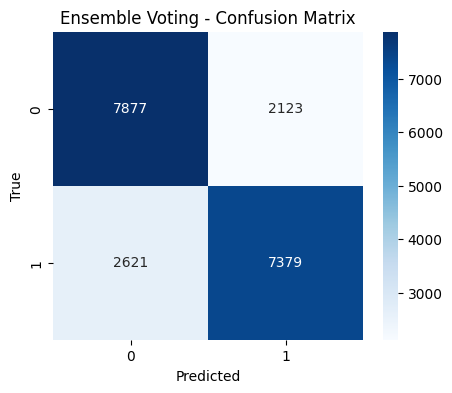

In [ ]:
# ============================
# IMPORTS
# ============================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from imblearn.over_sampling import SMOTE  # for balancing classes

# If XGBoost is installed
try:
    from xgboost import XGBClassifier
    xgb_available = True
except ImportError:
    xgb_available = False
    print("XGBoost not installed, skipping...")


# ============================
# DEFINE MODELS (DEFAULT PARAMS)
# ============================
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Naive Bayes": MultinomialNB(),
    "Linear SVM": LinearSVC(),
    "KNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(random_state=42),
}

if xgb_available:
    models["XGBoost"] = XGBClassifier(use_label_encoder=False, eval_metric="logloss")

# ============================
# TRAIN + EVALUATE MODELS
# ============================
for name, model in models.items():
    print("="*60)
    print(f"Training {name}...")

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    print(f"{name} Test Accuracy: {acc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=np.unique(y_test),
                yticklabels=np.unique(y_test))
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

# ============================
# ENSEMBLE VOTING
# ============================
estimators = [(name, model) for name, model in models.items()]
voting_clf = VotingClassifier(estimators=estimators, voting="hard")
voting_clf.fit(X_train, y_train)

y_pred = voting_clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("="*60)
print("Ensemble Voting Classifier")
print(f"Accuracy: {acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=np.unique(y_test),
            yticklabels=np.unique(y_test))
plt.title("Ensemble Voting - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


Baseline models + Tuned (LR and XGBOOST)

Training Logistic Regression...
Best Params for Logistic Regression: {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}


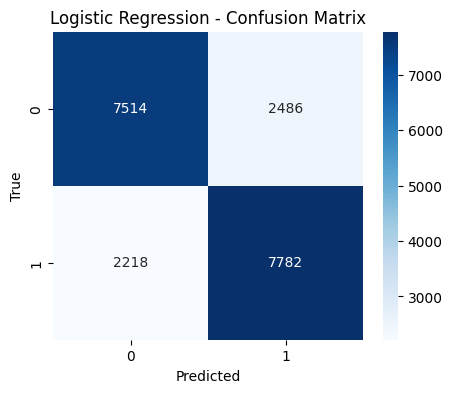

Training Naive Bayes...


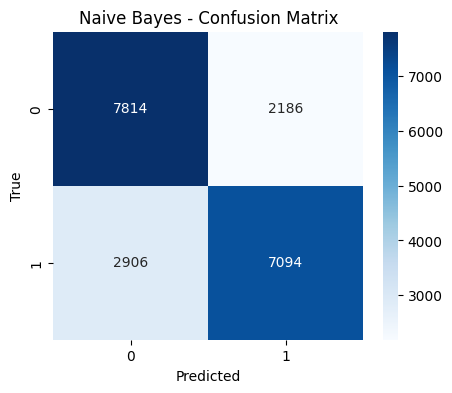

Training Linear SVM...


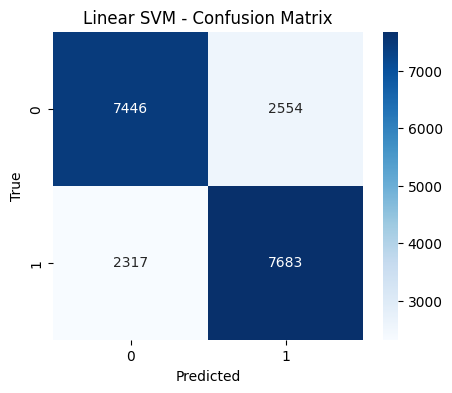

Training KNN...


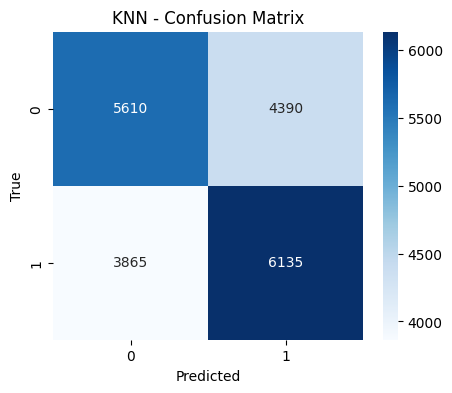

Training Decision Tree...


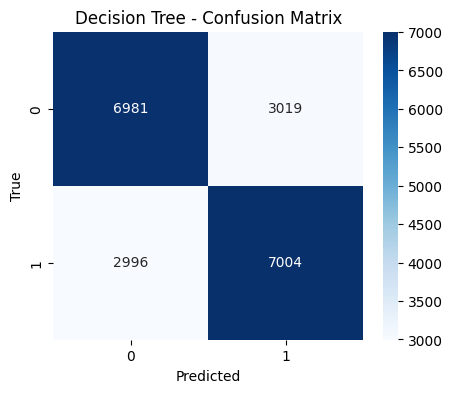

Training Random Forest...


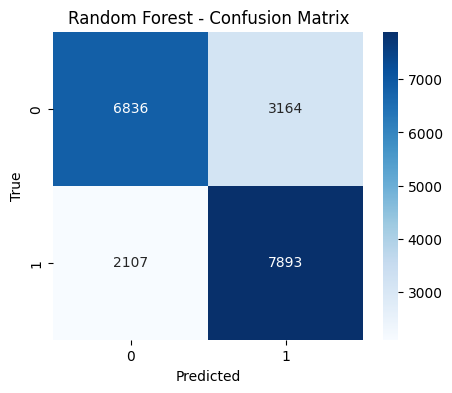

Training XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [08:51:45] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Params for XGBoost: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8}


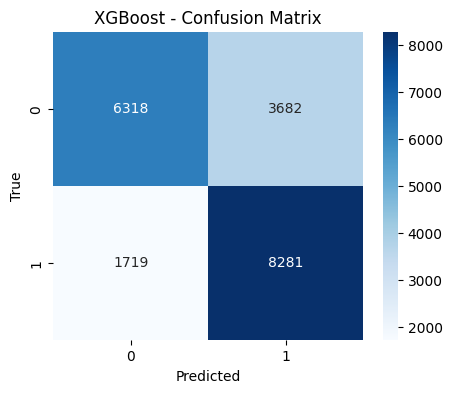

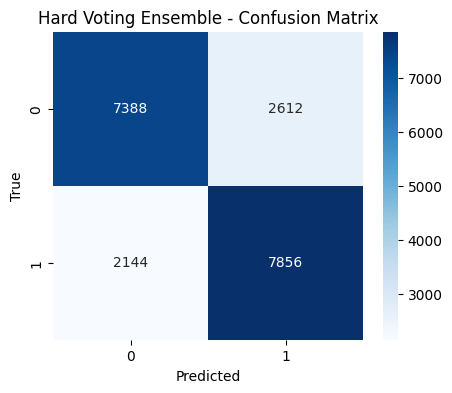


=== Metrics Table ===
                      Accuracy  Precision   Recall  F1-score   ROC-AUC
Logistic Regression    0.76480   0.764990  0.76480  0.764758  0.844552
Naive Bayes            0.74540   0.746679  0.74540  0.745070  0.830097
Linear SVM             0.75645   0.756594  0.75645  0.756416  0.836272
KNN                    0.58725   0.587491  0.58725  0.586965  0.627749
Decision Tree          0.69925   0.699251  0.69925  0.699250  0.701011
Random Forest          0.73645   0.739122  0.73645  0.735712  0.815931
XGBoost                0.72995   0.739166  0.72995  0.727323  0.808183
Hard Voting Ensemble   0.76220   0.762776  0.76220  0.762070       NaN


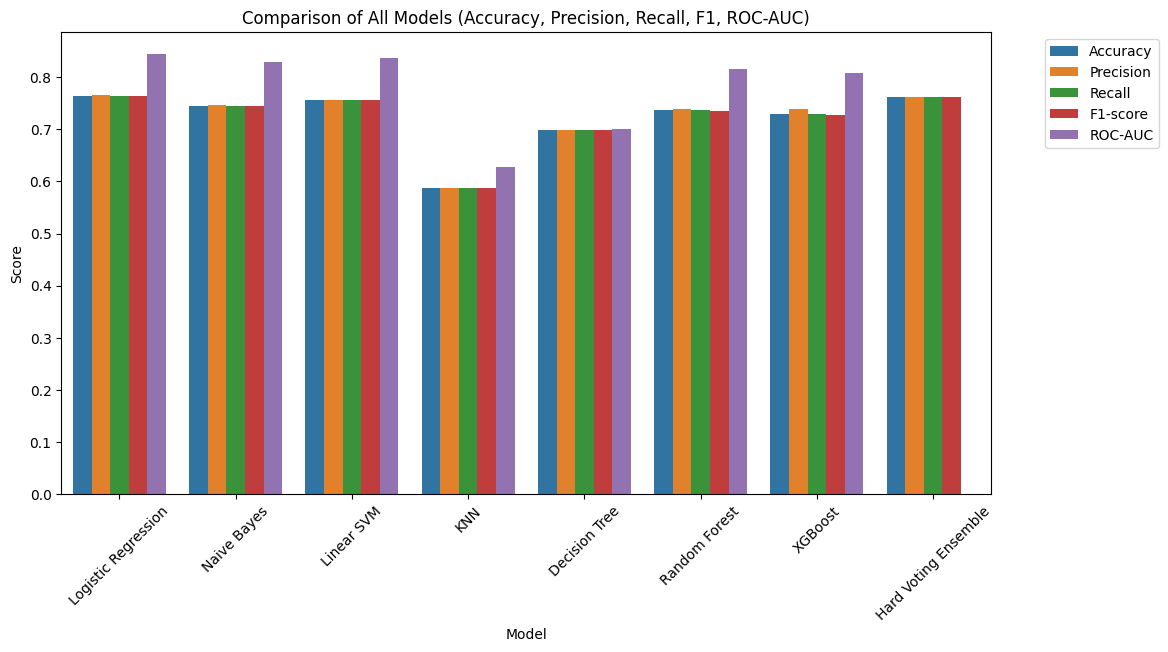

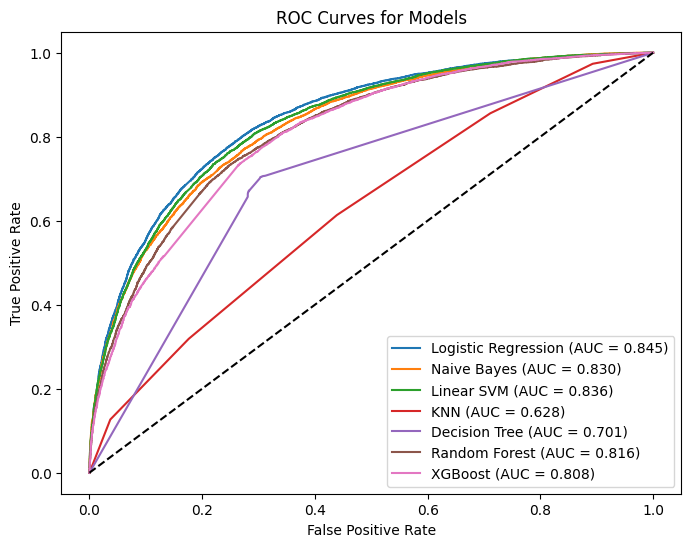

In [ ]:
# ============================
# IMPORTS
# ============================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from collections import Counter

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    precision_recall_fscore_support, roc_curve, auc, roc_auc_score
)
from sklearn.model_selection import GridSearchCV
from sklearn.calibration import CalibratedClassifierCV

from scipy.stats import mode


try:
    from xgboost import XGBClassifier
    xgb_available = True
except ImportError:
    xgb_available = False
    print("XGBoost not installed, skipping...")


# ============================
# BASE MODELS
# ============================
base_models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, solver="liblinear"),
    "Naive Bayes": MultinomialNB(),
    "Linear SVM": LinearSVC(max_iter=5000),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=200, max_depth=20),
}

if xgb_available:
    base_models["XGBoost"] = XGBClassifier(
        use_label_encoder=False,
        eval_metric="logloss",
        random_state=42
    )

# ============================
# PARAM GRIDS (only LR + XGB)
# ============================
param_grids = {
    "Logistic Regression": {
        "C": [0.5, 1, 2],
        "penalty": ["l1", "l2"],
        "solver": ["liblinear"]
    }
}

if xgb_available:
    param_grids["XGBoost"] = {
        "n_estimators": [100, 200],
        "max_depth": [4, 6],
        "learning_rate": [0.05, 0.1],
        "subsample": [0.8, 1.0],
    }

# ============================
# TRAIN + COLLECT METRICS
# ============================
metrics_list = {}
best_models = {}

for name, model in base_models.items():
    print("="*60)
    print(f"Training {name}...")

    if name in param_grids:  # tune LR + XGB
        grid = GridSearchCV(model, param_grids[name], cv=2, n_jobs=-1, verbose=0)
        grid.fit(X_train, y_train)
        best_models[name] = grid.best_estimator_
        print(f"Best Params for {name}: {grid.best_params_}")
    else:
        model.fit(X_train, y_train)
        best_models[name] = model

    # If model doesn't support predict_proba → wrap with calibration
    if hasattr(best_models[name], "predict_proba"):
        y_proba = best_models[name].predict_proba(X_test)[:, 1] if len(np.unique(y_test)) == 2 else None
    else:
        try:
            calibrated = CalibratedClassifierCV(best_models[name], cv=2)
            calibrated.fit(X_train, y_train)
            y_proba = calibrated.predict_proba(X_test)[:, 1] if len(np.unique(y_test)) == 2 else None
            best_models[name] = calibrated  # replace with calibrated
        except Exception:
            y_proba = None

    y_pred = best_models[name].predict(X_test)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average="macro", zero_division=0
    )

    metrics_list[name] = {
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "ROC-AUC": roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan
    }

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=np.unique(y_test),
                yticklabels=np.unique(y_test))
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

# ============================
# HARD VOTING ENSEMBLE (No retraining)
# ============================
# Collect predictions from already trained models
all_preds = []
for name, model in best_models.items():
    y_pred = model.predict(X_test)
    all_preds.append(y_pred)

# Stack predictions: shape (n_models, n_samples) → transpose
all_preds = np.array(all_preds).T

# Majority voting
y_pred_ensemble = mode(all_preds, axis=1).mode.flatten()

# Metrics for Ensemble
acc = accuracy_score(y_test, y_pred_ensemble)
precision, recall, f1, _ = precision_recall_fscore_support(
    y_test, y_pred_ensemble, average="macro", zero_division=0
)

metrics_list["Hard Voting Ensemble"] = {
    "Accuracy": acc,
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1,
    "ROC-AUC": np.nan  # not available for hard voting
}

# Confusion Matrix for Ensemble
cm = confusion_matrix(y_test, y_pred_ensemble)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=np.unique(y_test),
            yticklabels=np.unique(y_test))
plt.title("Hard Voting Ensemble - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# ============================
# METRICS TABLE
# ============================
metrics_df = pd.DataFrame(metrics_list).T
print("\n=== Metrics Table ===")
print(metrics_df)

# ============================
# BAR CHART COMPARISON
# ============================
metrics_melted = metrics_df.reset_index().melt(id_vars="index", var_name="Metric", value_name="Score")
plt.figure(figsize=(12, 6))
sns.barplot(data=metrics_melted, x="index", y="Score", hue="Metric")
plt.xticks(rotation=45)
plt.title("Comparison of All Models (Accuracy, Precision, Recall, F1, ROC-AUC)")
plt.ylabel("Score")
plt.xlabel("Model")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

# ============================
# ROC-AUC CURVES (only prob models)
# ============================
plt.figure(figsize=(8, 6))
for name, model in best_models.items():
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        plt.plot(fpr, tpr, label=f"{name} (AUC = {auc(fpr, tpr):.3f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Models")
plt.legend(loc="lower right")
plt.show()


Text vs Clean_tweet

In [ ]:
twitter_data.head()

,target,text,tweet_length,length_category,clean_tweet,orig_len,clean_len,orig_tokens,clean_tokens,special_tokens,hashtags,mentions,urls,emojis
0,0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",115,101-150,thats bummer shoulda got david carr third day,115,45,"[@switchfoot, http://twitpic.com/2y1zl, -, Aww...","[thats, bummer, shoulda, got, david, carr, thi...",14,0,1,2,11
1,0,is upset that he can't update his Facebook by ...,111,101-150,upset cant update facebook texting might cry r...,111,74,"[is, upset, that, he, can't, update, his, Face...","[upset, cant, update, facebook, texting, might...",6,0,0,0,6
2,0,@Kenichan I dived many times for the ball. Man...,89,51-100,dived many time ball managed save rest go bound,89,47,"[@Kenichan, I, dived, many, times, for, the, b...","[dived, many, time, ball, managed, save, rest,...",4,0,1,0,3
3,0,my whole body feels itchy and like its on fire,47,0-50,whole body feel itchy like fire,47,31,"[my, whole, body, feels, itchy, and, like, its...","[whole, body, feel, itchy, like, fire]",0,0,0,0,0
4,0,"@nationwideclass no, it's not behaving at all....",111,101-150,behaving im mad cant see,111,24,"[@nationwideclass, no,, it's, not, behaving, a...","[behaving, im, mad, cant, see]",9,0,1,0,8


In [ ]:
df_sample.head()

,target,text,tweet_length,length_category,clean_tweet,orig_len,clean_len,orig_tokens,clean_tokens,hashtags,mentions,urls,emojis
0,0,Had a good 3 hour nap..I don't know how I'm go...,73,51-100,good hour napi dont know im gonna pas english ...,73,51,"[Had, a, good, 3, hour, nap..I, don't, know, h...","[good, hour, napi, dont, know, im, gonna, pas,...",0,0,0,4
1,0,is scared that she might not get the job that ...,98,51-100,scared might get job want im still hoping wish...,98,53,"[is, scared, that, she, might, not, get, the, ...","[scared, might, get, job, want, im, still, hop...",0,0,0,1
2,1,@GenderQ Thanks A friend of mine always says ...,118,101-150,thanks friend mine always say like pretty ligh...,118,76,"[@GenderQ, Thanks, A, friend, of, mine, always...","[thanks, friend, mine, always, say, like, pret...",0,1,0,7
3,0,had an absolutely amazing weekend but now stuc...,70,51-100,absolutely amazing weekend stuck babbage work,70,45,"[had, an, absolutely, amazing, weekend, but, n...","[absolutely, amazing, weekend, stuck, babbage,...",0,0,0,0
4,0,i had really weird dream last night...but i wi...,73,51-100,really weird dream last nightbut wish didnt wake,73,48,"[i, had, really, weird, dream, last, night...b...","[really, weird, dream, last, nightbut, wish, d...",0,0,0,3


In [ ]:
twitter_data['clean_tweet_length'] = twitter_data['clean_tweet'].apply(len)
twitter_data.head()

,target,text,tweet_length,length_category,clean_tweet,clean_tweet_length
0,0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",115,101-150,thats bummer shoulda got david carr third day,45
1,0,is upset that he can't update his Facebook by ...,111,101-150,upset cant update facebook texting might cry r...,74
2,0,@Kenichan I dived many times for the ball. Man...,89,51-100,dived many time ball managed save rest go bound,47
3,0,my whole body feels itchy and like its on fire,47,0-50,whole body feel itchy like fire,31
4,0,"@nationwideclass no, it's not behaving at all....",111,101-150,behaving im mad cant see,24


In [ ]:
df_sample['clean_tweet_length']  = df_sample['clean_tweet'].apply(len)
df_sample.head()

,target,text,tweet_length,length_category,clean_tweet,clean_tweet_length
0,0,Had a good 3 hour nap..I don't know how I'm go...,73,51-100,good hour napi dont know im gonna pas english ...,51
1,0,is scared that she might not get the job that ...,98,51-100,scared might get job want im still hoping wish...,53
2,1,@GenderQ Thanks A friend of mine always says ...,118,101-150,thanks friend mine always say like pretty ligh...,76
3,0,had an absolutely amazing weekend but now stuc...,70,51-100,absolutely amazing weekend stuck babbage work,45
4,0,i had really weird dream last night...but i wi...,73,51-100,really weird dream last nightbut wish didnt wake,48


Histogram showing clean_tweet_length ditribution

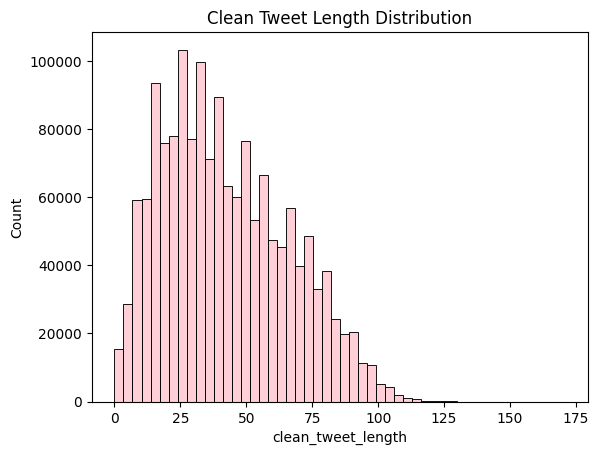

In [ ]:
sns.histplot(twitter_data['clean_tweet_length'], bins=50, color='pink')
plt.title("Clean Tweet Length Distribution")
plt.show()

Visual Comparision between 'Original Tweet Length' and 'Clean Tweet Length'

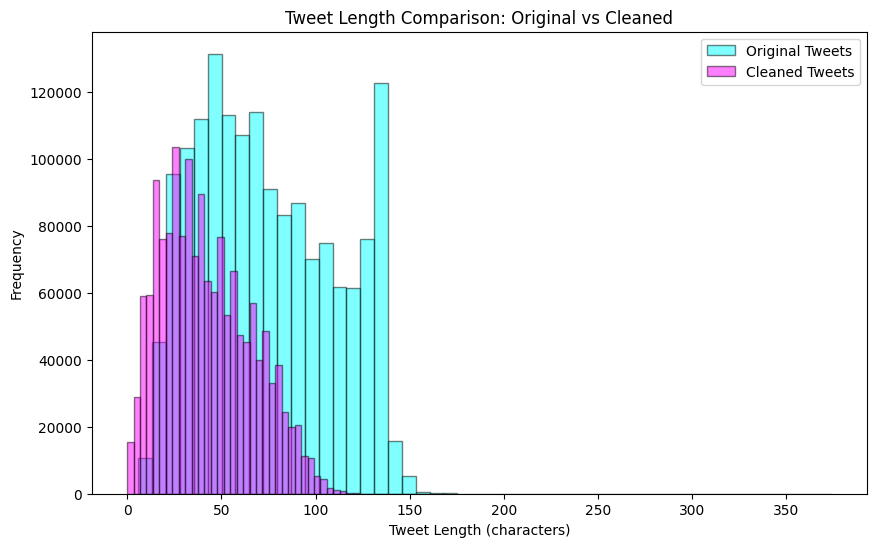

In [ ]:
# Plot comparison
plt.figure(figsize=(10,6))
plt.hist(twitter_data['tweet_length'], bins=50, alpha=0.5, label='Original Tweets', color='cyan', edgecolor='black')
plt.hist(twitter_data['clean_tweet_length'], bins=50, alpha=0.5, label='Cleaned Tweets', color='magenta', edgecolor='black')

plt.title('Tweet Length Comparison: Original vs Cleaned')
plt.xlabel('Tweet Length (characters)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

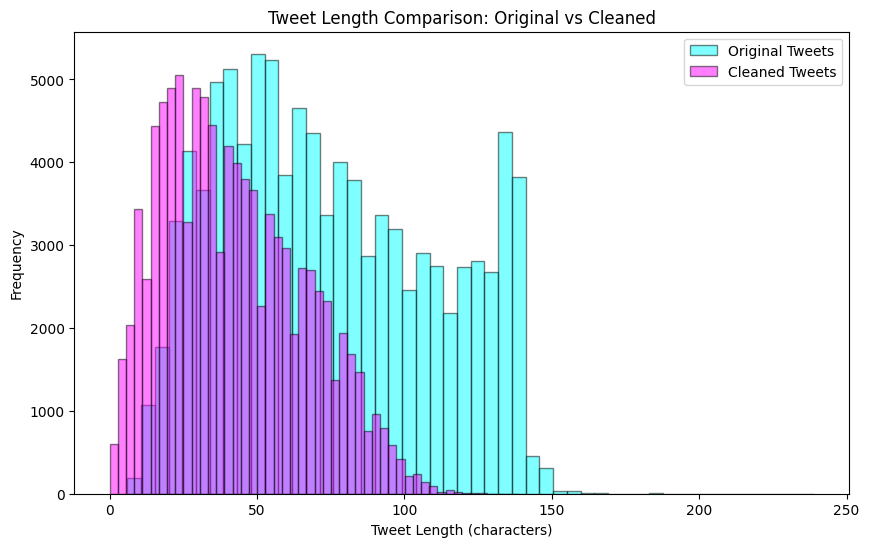

In [ ]:
# Plot comparison
plt.figure(figsize=(10,6))
plt.hist(df_sample['tweet_length'], bins=50, alpha=0.5, label='Original Tweets', color='cyan', edgecolor='black')
plt.hist(df_sample['clean_tweet_length'], bins=50, alpha=0.5, label='Cleaned Tweets', color='magenta', edgecolor='black')

plt.title('Tweet Length Comparison: Original vs Cleaned')
plt.xlabel('Tweet Length (characters)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [ ]:
twitter_data['target'].value_counts()

,count
target,
1,791281
0,790185


In [ ]:
df_sample['target'].value_counts()

,count
target,
0,50000
1,50000


Word Cloud and most Used Words -- on Clean_tweets

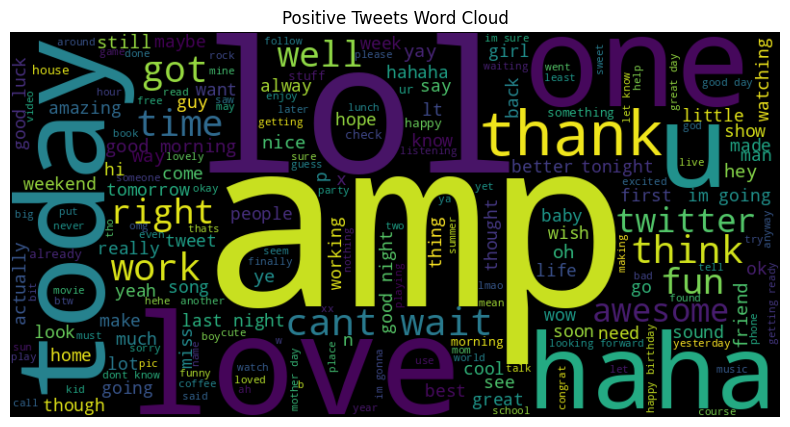

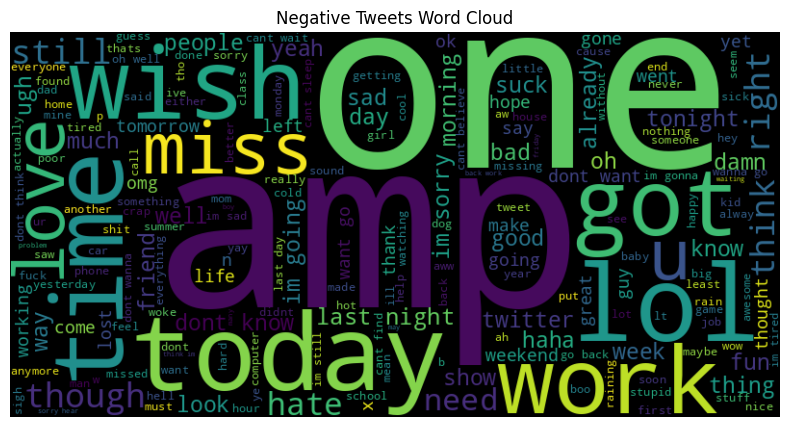

In [ ]:
# Word Cloud

from wordcloud import WordCloud

neg_text = " ".join(twitter_data[twitter_data['target'] == 0]['clean_tweet'])
pos_text = " ".join(twitter_data[twitter_data['target'] == 1]['clean_tweet'])

# Positive tweets word cloud
pos_wc = WordCloud(width=800, height=400).generate(pos_text)
plt.figure(figsize=(10, 5))
plt.imshow(pos_wc, interpolation='bilinear')
plt.axis("off")
plt.title("Positive Tweets Word Cloud")
plt.show()

# Negative tweets word cloud
neg_wc = WordCloud(width=800, height=400).generate(neg_text)
plt.figure(figsize=(10, 5))
plt.imshow(neg_wc, interpolation='bilinear')
plt.axis("off")
plt.title("Negative Tweets Word Cloud")
plt.show()


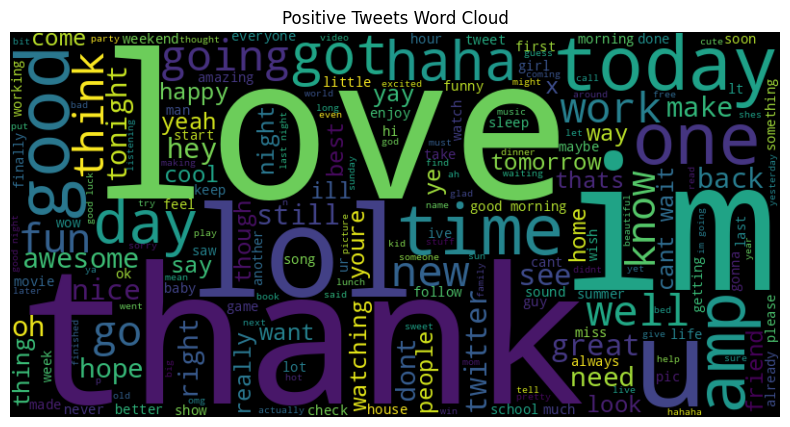

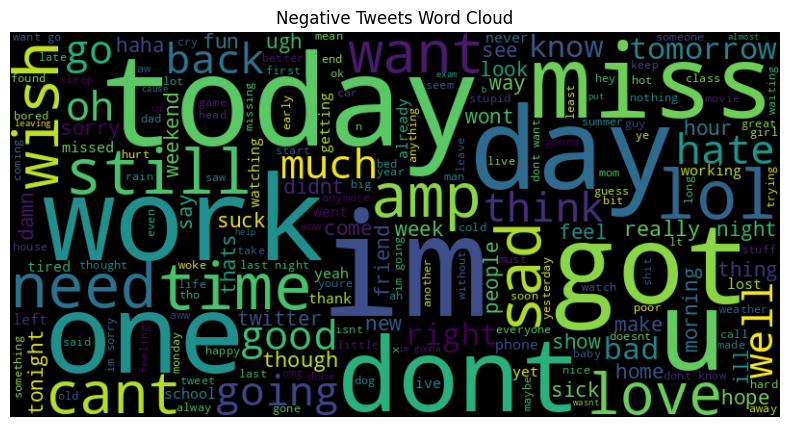

In [ ]:
# Word Cloud

from wordcloud import WordCloud

neg_text = " ".join(df_sample[df_sample['target'] == 0]['clean_tweet'])
pos_text = " ".join(df_sample[df_sample['target'] == 1]['clean_tweet'])

# Positive tweets word cloud
pos_wc = WordCloud(width=800, height=400).generate(pos_text)
plt.figure(figsize=(10, 5))
plt.imshow(pos_wc, interpolation='bilinear')
plt.axis("off")
plt.title("Positive Tweets Word Cloud")
plt.show()

# Negative tweets word cloud
neg_wc = WordCloud(width=800, height=400).generate(neg_text)
plt.figure(figsize=(10, 5))
plt.imshow(neg_wc, interpolation='bilinear')
plt.axis("off")
plt.title("Negative Tweets Word Cloud")
plt.show()


Model saving

In [ ]:
from joblib import dump

dump(model, "model.joblib")
dump(vectorizer, "vectorizer.joblib")